In [1]:
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

In [2]:
adata_rna=sc.read_h5ad(r"D:\GP\Datasets\cbmc_rna_filtered.h5ad")
adata_rna

adata_rna.obs.head()

,size_factors
AAACCTGAGAAACCGC,1841.0
AAACCTGAGCAGGTCA,1839.0
AAACCTGAGGCATGGT,1649.0
AAACCTGAGTGGTCCC,1752.0
AAACCTGCAAGGTTCT,4003.0


In [3]:
# swap the var id to have the values from gene_symbols
adata_rna.var["gene_symbols"] = adata_rna.var["gene_symbols"].astype(str)

# set gene symbols as new index
adata_rna.var_names = adata_rna.var["gene_symbols"]

# optional but recommended: remove duplicates
adata_rna = adata_rna[:, ~adata_rna.var_names.duplicated()].copy()

In [4]:
adata_rna.var.head()

,n_counts,feature_name,hvg,hvg_score,gene_symbols
gene_symbols,,,,,
A1BG,7.0,HUMAN_A1BG,False,0.46490699135472746,A1BG
A1BG-AS1,22.0,HUMAN_A1BG-AS1,False,0.40879803825589356,A1BG-AS1
A1CF,3.0,HUMAN_A1CF,False,0.4587354678010472,A1CF
A2M,16.0,HUMAN_A2M,False,0.43117187790241857,A2M
A2M-AS1,170.0,HUMAN_A2M-AS1,False,0.2899705160233493,A2M-AS1


In [5]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [6]:
adata_rna.layers["counts"] = adata_rna.X.copy()

In [7]:
from scimilarity.utils import align_dataset, lognorm_counts
adata_rna = align_dataset(adata_rna, ce.gene_order)
adata_rna = lognorm_counts(adata_rna)

In [8]:
X = adata_rna.layers["counts"]
embeddings = ce.get_embeddings(X)
print(embeddings.shape)

(8617, 128)


In [9]:
print(type(X))
print(X.dtype)

<class 'scipy.sparse._csr.csr_matrix'>
float64


In [10]:
adata_rna.obsm["X_emb"] = embeddings
print(adata_rna.obsm["X_emb"].shape)

(8617, 128)


In [11]:
adata_adt=sc.read_h5ad(r"D:\GP\Datasets\cbmc_adt.h5ad")
adata_adt

adata_adt.X = adata_adt.layers["counts"].copy()
print(adata_adt.X)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 112019 stored elements and shape (8617, 13)>
  Coords	Values
  (0, 0)	936.0
  (0, 1)	1088.0
  (0, 2)	23.0
  (0, 3)	3324.0
  (0, 4)	24.0
  (0, 5)	43.0
  (0, 6)	18.0
  (0, 7)	12.0
  (0, 8)	382.0
  (0, 9)	39.0
  (0, 10)	17.0
  (0, 11)	28.0
  (0, 12)	72.0
  (1, 0)	55.0
  (1, 1)	132.0
  (1, 2)	46.0
  (1, 3)	330.0
  (1, 4)	65.0
  (1, 5)	76.0
  (1, 6)	74.0
  (1, 7)	605.0
  (1, 8)	671.0
  (1, 9)	50.0
  (1, 10)	80.0
  (1, 11)	51.0
  :	:
  (8615, 1)	41.0
  (8615, 2)	63.0
  (8615, 3)	16126.0
  (8615, 4)	271.0
  (8615, 5)	250.0
  (8615, 6)	53.0
  (8615, 7)	142.0
  (8615, 8)	71.0
  (8615, 9)	106.0
  (8615, 10)	37.0
  (8615, 11)	81.0
  (8615, 12)	43.0
  (8616, 0)	27.0
  (8616, 1)	40.0
  (8616, 2)	33.0
  (8616, 3)	197.0
  (8616, 4)	21.0
  (8616, 5)	33.0
  (8616, 6)	20.0
  (8616, 7)	209.0
  (8616, 8)	320.0
  (8616, 9)	15.0
  (8616, 10)	21.0
  (8616, 11)	23.0
  (8616, 12)	16.0


In [12]:
import muon 
muon.prot.pp.clr(adata_adt)
adata_adt.layers["clr"] = adata_adt.X.copy()

y = adata_adt.layers["clr"]

In [13]:
X_new = adata_rna.obsm["X_emb"]

In [14]:

X_new = X_new.toarray() if hasattr(X_new, "toarray") else X_new
y = y.toarray() if hasattr(y, "toarray") else y


# Model

In [48]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X_new):
    X_train, X_test = X_new[train_idx], X_new[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [32]:
import numpy as np
from sklearn.metrics import mean_squared_error

# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.1217577866845902
Per-protein MSE: [0.09688543 0.08677653 0.51871587 0.14037164 0.12481876 0.08474968
 0.07303331 0.09002687 0.06743275 0.09170636 0.07525162 0.07310964
 0.05997277]
Per-protein MSE shape: (13,)


In [33]:
rmse_per_protein = np.sqrt(mse_per_protein)
avg_rmse = rmse_per_protein.mean()

print("Avg RMSE:", avg_rmse)
print("Per-protein RMSE:", rmse_per_protein)
print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg RMSE: 0.3282723864581913
Per-protein RMSE: [0.31126424 0.29457856 0.72021932 0.37466204 0.35329698 0.29111799
 0.27024676 0.30004478 0.25967816 0.30283057 0.27432028 0.27038795
 0.24489338]
Per-protein RMSE shape: (13,)


In [34]:
from scipy.stats import pearsonr

pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

print("Avg Pearson correlation:", mean_pearson)
print("Per-protein Pearson correlation:", pearson_per_protein)
print("Per-protein Pearson shape:", pearson_per_protein.shape)

Avg Pearson correlation: 0.7493820902295835
Per-protein Pearson correlation: [0.93279732 0.91469956 0.69828606 0.84477392 0.73830643 0.79551186
 0.50881857 0.92861473 0.81023523 0.83424892 0.65865625 0.57680551
 0.50021283]
Per-protein Pearson shape: (13,)


In [35]:
from scipy.stats import spearmanr

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

print("Mean Spearman correlation:", mean_spearman)
print("Per-protein Spearman correlation:", spearman_per_protein)
print("Per-protein Spearman shape:", spearman_per_protein.shape)

Mean Spearman correlation: 0.643968681197754
Per-protein Spearman correlation: [0.80982982 0.84431319 0.44044664 0.83781503 0.65586083 0.59515678
 0.41353723 0.82784192 0.76208105 0.57463402 0.58746625 0.51860842
 0.50400169]
Per-protein Spearman shape: (13,)


In [36]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: CCR7 (Pearson = 0.5002)
Median: CD16 (Pearson = 0.7955)
Best: CD3 (Pearson = 0.9328)


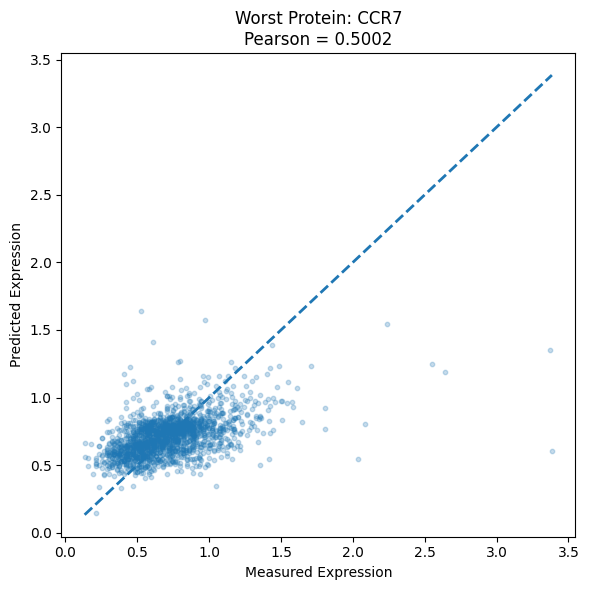

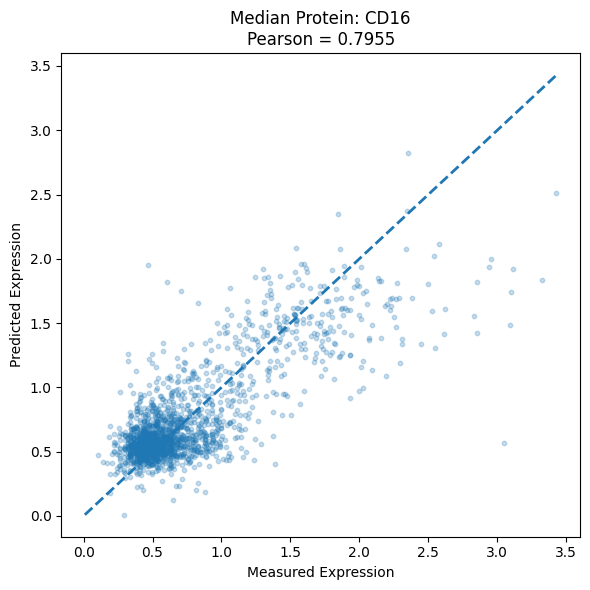

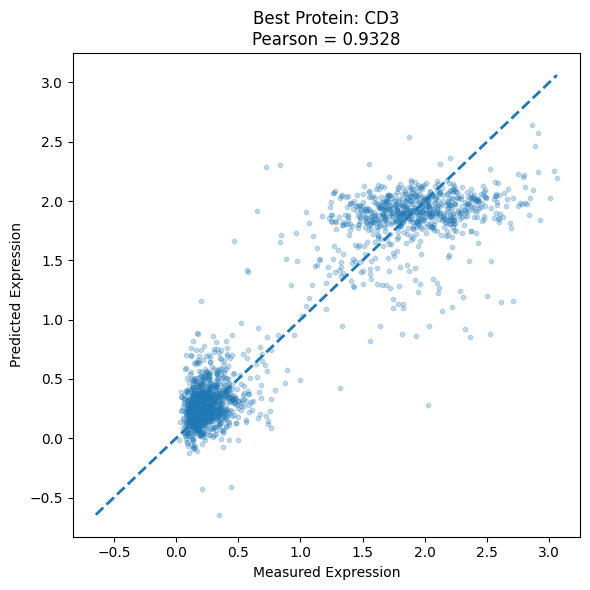

In [37]:
import matplotlib.pyplot as plt
for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path
import numpy as np

save_path = Path("D:/GP/Notebooks/Scimilarity/")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "SCimilarity"  # change per notebook

np.savez(
    save_path / f"{model_name}_CBMCs_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for SCimilarity at: D:\GP\Notebooks\Scimilarity
